## Load the data

In [32]:
from datasets import load_dataset, Dataset
import pyarrow as pa
import pyarrow.compute as pc

# Load dataset 
dataset_stream = load_dataset(
    "ejhusom/llm-inference-energy-consumption",
    split="train",
    streaming=True
)

# Convert to list and fix the problematic column
data_list = []
for example in dataset_stream:
    # Convert energy_consumption_llm_gpu from int to float
    if 'energy_consumption_llm_gpu' in example:
        example['energy_consumption_llm_gpu'] = float(example['energy_consumption_llm_gpu'])
    data_list.append(example)

# Create a proper dataset
dataset = Dataset.from_list(data_list)

print("Dataset loaded successfully!")
print(f"Total examples: {len(dataset)}")
print("\nColumns:", dataset.column_names)

# Now check for hardware type information
if "type" in dataset.column_names:
    unique_types = dataset.unique("type")
    print("\nUnique values in 'type' column:")
    for t in unique_types:
        print(f"  - {t}")
else:
    print("\nNo 'type' column found")

# Check model names 
if "model_name" in dataset.column_names:
    unique_models = dataset.unique("model_name")
    print("\nUnique models:")
    for m in unique_models:
        print(f"  - {m}")

Dataset loaded successfully!
Total examples: 78728

Columns: ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'index', 'model_name', 'created_at', 'total_duration', 'load_duration', 'prompt_token_length', 'prompt_duration', 'response_token_length', 'response_duration', 'prompt', 'response', 'energy_consumption_monitoring', 'energy_consumption_llm_cpu', 'type', 'clock_duration', 'start_time', 'end_time', 'energy_consumption_llm_total', 'energy_consumption_llm', 'word_count', 'sentence_count', 'avg_word_length', 'word_diversity', 'unique_word_count', 'avg_sentence_length', 'punctuation_count', 'stop_word_count', 'long_word_count', 'named_entity_count', 'noun_count', 'verb_count', 'adj_count', 'adverb_count', 'pronoun_count', 'prop_adverbs', 'prop_pronouns', 'sentiment_polarity', 'sentiment_subjectivity', 'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index', 'automated_readability_index', 'coleman_liau_index', 'linsear_write_formula', 'dale_chall_readability_score', 't

In [33]:
df = dataset.to_pandas()

print(f"DataFrame créé avec {len(df)} lignes et {len(df.columns)} colonnes")
print("\nAperçu des premières lignes :")
print(df.head())

# Check data types
print("\nTypes de données :")
print(df.dtypes)

# Model information
print("\nDistribution des modèles :")
print(df['model_name'].value_counts())

# Energy consumption statistics by model
print("\nConsommation d'énergie moyenne par modèle :")
print(df.groupby('model_name')['energy_consumption_llm_total'].mean().sort_values(ascending=False))

DataFrame créé avec 78728 lignes et 80 colonnes

Aperçu des premières lignes :
   Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  index    model_name  \
0           0.0           0.0           0      0  codellama:7b   
1           1.0           1.0           1      0  codellama:7b   
2           2.0           2.0           2      0  codellama:7b   
3           3.0           3.0           3      0  codellama:7b   
4           4.0           4.0           4      0  codellama:7b   

                            created_at  total_duration  load_duration  \
0  2024-05-20 01:29:27.691485835+00:00    2.167467e+11       312573.0   
1  2024-05-20 01:30:34.454555386+00:00    6.272181e+10       433357.0   
2  2024-05-20 01:34:30.874894395+00:00    2.362132e+11       419348.0   
3  2024-05-20 01:36:11.699366237+00:00    9.673783e+10       365109.0   
4  2024-05-20 01:38:59.260219141+00:00    1.640967e+11       312792.0   

   prompt_token_length  prompt_duration  ...  named_entities  adjectives  \
0        

In [34]:
df.head(50)

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,index,model_name,created_at,total_duration,load_duration,prompt_token_length,prompt_duration,...,named_entities,adjectives,adverbs,length_x_complexity,questions_about_entities,desc_complexity_ratio,word_count_squared,avg_sentence_length_cubed,lexical_diversity,energy_consumption_llm_gpu
0,0.0,0.0,0,0,codellama:7b,2024-05-20 01:29:27.691485835+00:00,2.167467e+11,312573.0,NaN,6.298400e+08,...,0.0,1.0,1.0,0.000000,0.0,0.090909,484.0,1.064800e+04,0.818182,0.0
1,1.0,1.0,1,0,codellama:7b,2024-05-20 01:30:34.454555386+00:00,6.272181e+10,433357.0,39.0,1.437697e+10,...,0.0,1.0,0.0,0.000000,0.0,0.029412,1156.0,3.930400e+04,0.823529,0.0
2,2.0,2.0,2,0,codellama:7b,2024-05-20 01:34:30.874894395+00:00,2.362132e+11,419348.0,35.0,1.301101e+10,...,0.0,1.0,0.0,0.521990,0.0,0.038462,676.0,2.197000e+03,0.807692,0.0
3,3.0,3.0,3,0,codellama:7b,2024-05-20 01:36:11.699366237+00:00,9.673783e+10,365109.0,83.0,2.896404e+10,...,3.0,2.0,0.0,2.469388,0.0,0.030303,4356.0,3.593700e+04,0.681818,0.0
4,4.0,4.0,4,0,codellama:7b,2024-05-20 01:38:59.260219141+00:00,1.640967e+11,312792.0,34.0,1.197915e+10,...,0.0,2.0,4.0,0.652832,0.0,0.222222,729.0,2.460375e+03,0.925926,0.0
5,5.0,5.0,5,0,codellama:7b,2024-05-20 01:41:13.600159551+00:00,1.304500e+11,403444.0,35.0,1.327334e+10,...,0.0,3.0,1.0,0.588463,0.0,0.137931,841.0,3.048625e+03,0.862069,0.0
6,6.0,6.0,6,0,codellama:7b,2024-05-20 01:44:30.746154740+00:00,1.936168e+11,352542.0,90.0,3.236809e+10,...,1.0,4.0,2.0,1.014687,0.0,0.090909,4356.0,1.064800e+04,0.651515,0.0
7,7.0,7.0,7,0,codellama:7b,2024-05-20 01:47:50.308210414+00:00,1.956777e+11,408487.0,34.0,1.260279e+10,...,0.0,3.0,2.0,0.492407,0.0,0.172414,841.0,3.048625e+03,0.965517,0.0
8,8.0,8.0,8,0,codellama:7b,2024-05-20 01:51:11.251601568+00:00,1.969329e+11,427450.0,25.0,9.839053e+09,...,0.0,0.0,0.0,0.000000,0.0,0.000000,400.0,8.000000e+03,0.950000,0.0
9,9.0,9.0,9,0,codellama:7b,2024-05-20 01:56:09.222663254+00:00,2.941100e+11,330827.0,269.0,9.645652e+10,...,9.0,10.0,1.0,7.505467,0.0,0.050459,47524.0,3.020476e+04,0.417431,0.0


In [35]:
df["type"].unique()

array(['unknown'], dtype=object)

## Pre-Processing 

### Missing Values :

In [36]:
missing_values = df.isnull().sum()
print("Nombre de valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])

Nombre de valeurs manquantes par colonne :
Unnamed: 0.2             68034
Unnamed: 0.1             46445
total_duration              38
load_duration               38
prompt_token_length        303
prompt_duration             38
response_token_length       38
response_duration           38
response                     4
dtype: int64


In [37]:
# Drop columns with a high percentage of missing values
df = df.drop(columns=['Unnamed: 0.2', 'Unnamed: 0.1'])

# Impute numerical columns with median
numerical_cols_to_impute = ['total_duration', 'load_duration', 'prompt_token_length',
                            'prompt_duration', 'response_token_length', 'response_duration']
for col in numerical_cols_to_impute:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Drop rows with missing values in 'response'
df.dropna(subset=['response'], inplace=True)

# Verify that missing values have been handled
missing_values_after = df.isnull().sum()
print("\nNombre de valeurs manquantes par colonne après traitement :")
print(missing_values_after[missing_values_after > 0])


Nombre de valeurs manquantes par colonne après traitement :
Series([], dtype: int64)


### Data type conversion :

In [38]:
import pandas as pd
# Examine the data types
print("Original data types:")
print(df.dtypes)

# Identify columns to convert and Convert
# Convert datetime columns
datetime_cols = ['created_at', 'start_time', 'end_time']
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert numerical columns that might be objects
numerical_cols = [
    'total_duration', 'load_duration', 'prompt_token_length',
    'prompt_duration', 'response_token_length', 'response_duration',
    'energy_consumption_monitoring', 'energy_consumption_llm_cpu',
    'energy_consumption_llm_total', 'energy_consumption_llm',
    'word_count', 'sentence_count', 'avg_word_length', 'word_diversity',
    'unique_word_count', 'avg_sentence_length', 'punctuation_count',
    'stop_word_count', 'long_word_count', 'named_entity_count', 'noun_count',
    'verb_count', 'adj_count', 'adverb_count', 'pronoun_count', 'prop_adverbs',
    'prop_pronouns', 'sentiment_polarity', 'sentiment_subjectivity',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
    'automated_readability_index', 'coleman_liau_index', 'linsear_write_formula',
    'dale_chall_readability_score', 'spache_readability', 'mcalpine_eflaw',
    'reading_time', 'fernandez_huerta', 'szigriszt_pazos', 'gutierrez_polini',
    'crawford', 'osman', 'gulpease_index', 'wiener_sachtextformel',
    'syllable_count', 'lexicon_count', 'char_count', 'letter_count',
    'polysyllabcount', 'monosyllabcount', 'question_marks', 'exclamation_marks',
    'sentence_embedding_variance', 'personal_pronouns', 'named_entities',
    'adjectives', 'adverbs', 'length_x_complexity', 'questions_about_entities',
    'desc_complexity_ratio', 'word_count_squared', 'avg_sentence_length_cubed',
    'lexical_diversity', 'energy_consumption_llm_gpu'
]

for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nData types after conversion:")
print(df.dtypes)

Original data types:
Unnamed: 0                      int64
index                           int64
model_name                     object
created_at                     object
total_duration                float64
                               ...   
desc_complexity_ratio         float64
word_count_squared            float64
avg_sentence_length_cubed     float64
lexical_diversity             float64
energy_consumption_llm_gpu    float64
Length: 78, dtype: object

Data types after conversion:
Unnamed: 0                                  int64
index                                       int64
model_name                                 object
created_at                    datetime64[ns, UTC]
total_duration                            float64
                                     ...         
desc_complexity_ratio                     float64
word_count_squared                        float64
avg_sentence_length_cubed                 float64
lexical_diversity                         float64
energ

### Duplicates :

In [39]:
# Identify duplicate rows
duplicate_rows = df.duplicated()

# Count the total number of duplicate rows
num_duplicate_rows = duplicate_rows.sum()
print(f"Number of duplicate rows: {num_duplicate_rows}")

# Handle duplicates if necessary
if num_duplicate_rows > 0:
    print("Removing duplicate rows...")
    df_before_dropping = df.shape[0]
    df = df.drop_duplicates()
    df_after_dropping = df.shape[0]
    print(f"Number of rows before dropping duplicates: {df_before_dropping}")
    print(f"Number of rows after dropping duplicates: {df_after_dropping}")
else:
    print("No duplicate rows found.")

# Verify that duplicate rows have been removed
num_duplicate_rows_after = df.duplicated().sum()
print(f"Number of duplicate rows after dropping: {num_duplicate_rows_after}")

Number of duplicate rows: 5347
Removing duplicate rows...
Number of rows before dropping duplicates: 78724
Number of rows after dropping duplicates: 73377
Number of duplicate rows after dropping: 0


### Outliers : 

Descriptive statistics for selected numerical columns:


,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,energy_consumption_llm_cpu,energy_consumption_llm_total,energy_consumption_llm,energy_consumption_llm_gpu,...,personal_pronouns,named_entities,adjectives,adverbs,length_x_complexity,questions_about_entities,desc_complexity_ratio,word_count_squared,avg_sentence_length_cubed,lexical_diversity
count,7.337700e+04,7.337700e+04,73377.000000,7.337700e+04,73377.000000,7.337700e+04,7.337700e+04,73377.000000,73377.000000,73377.000000,...,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,7.337700e+04,7.337700e+04,73377.000000
mean,2.343126e+10,3.515385e+06,58.612685,1.912775e+09,274.774439,2.144149e+10,4.561624e-05,0.000151,0.000151,0.000105,...,0.296442,2.320959,2.521512,0.808823,2.036674,0.373864,0.122968,8.483285e+03,3.334516e+05,1.107907
std,8.308117e+10,1.113817e+08,100.255855,6.099519e+09,1310.462023,8.160141e+10,3.809139e-04,0.000784,0.000784,0.000692,...,0.889239,6.631279,5.082175,1.862177,5.844586,4.463129,0.237374,5.704328e+04,2.680494e+07,1.013536
min,2.062720e+08,1.509040e+05,5.000000,1.222200e+07,2.000000,1.857900e+07,0.000000e+00,0.000003,0.000003,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000e+00,1.478813e+01,0.034483
25%,3.174785e+09,7.281410e+05,18.000000,1.546270e+08,61.000000,2.637012e+09,4.523581e-08,0.000029,0.000029,0.000020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.210000e+02,7.290000e+02,0.818182
50%,6.743699e+09,1.295035e+06,26.000000,2.378590e+08,248.000000,5.806068e+09,1.039090e-07,0.000080,0.000080,0.000065,...,0.000000,1.000000,1.000000,0.000000,0.541090,0.000000,0.076923,4.000000e+02,1.728000e+03,0.923077
75%,1.574297e+10,1.732869e+06,43.000000,1.410540e+09,412.000000,1.365249e+10,1.291692e-06,0.000165,0.000165,0.000132,...,0.000000,2.000000,3.000000,1.000000,1.249826,0.000000,0.142857,1.089000e+03,6.331625e+03,1.000000
max,1.046414e+13,8.831648e+09,1977.000000,2.788707e+11,285702.000000,1.046098e+13,2.728760e-02,0.143786,0.143786,0.143782,...,27.000000,391.000000,229.000000,87.000000,135.601152,245.000000,11.647059,3.928324e+06,3.067587e+09,19.058824


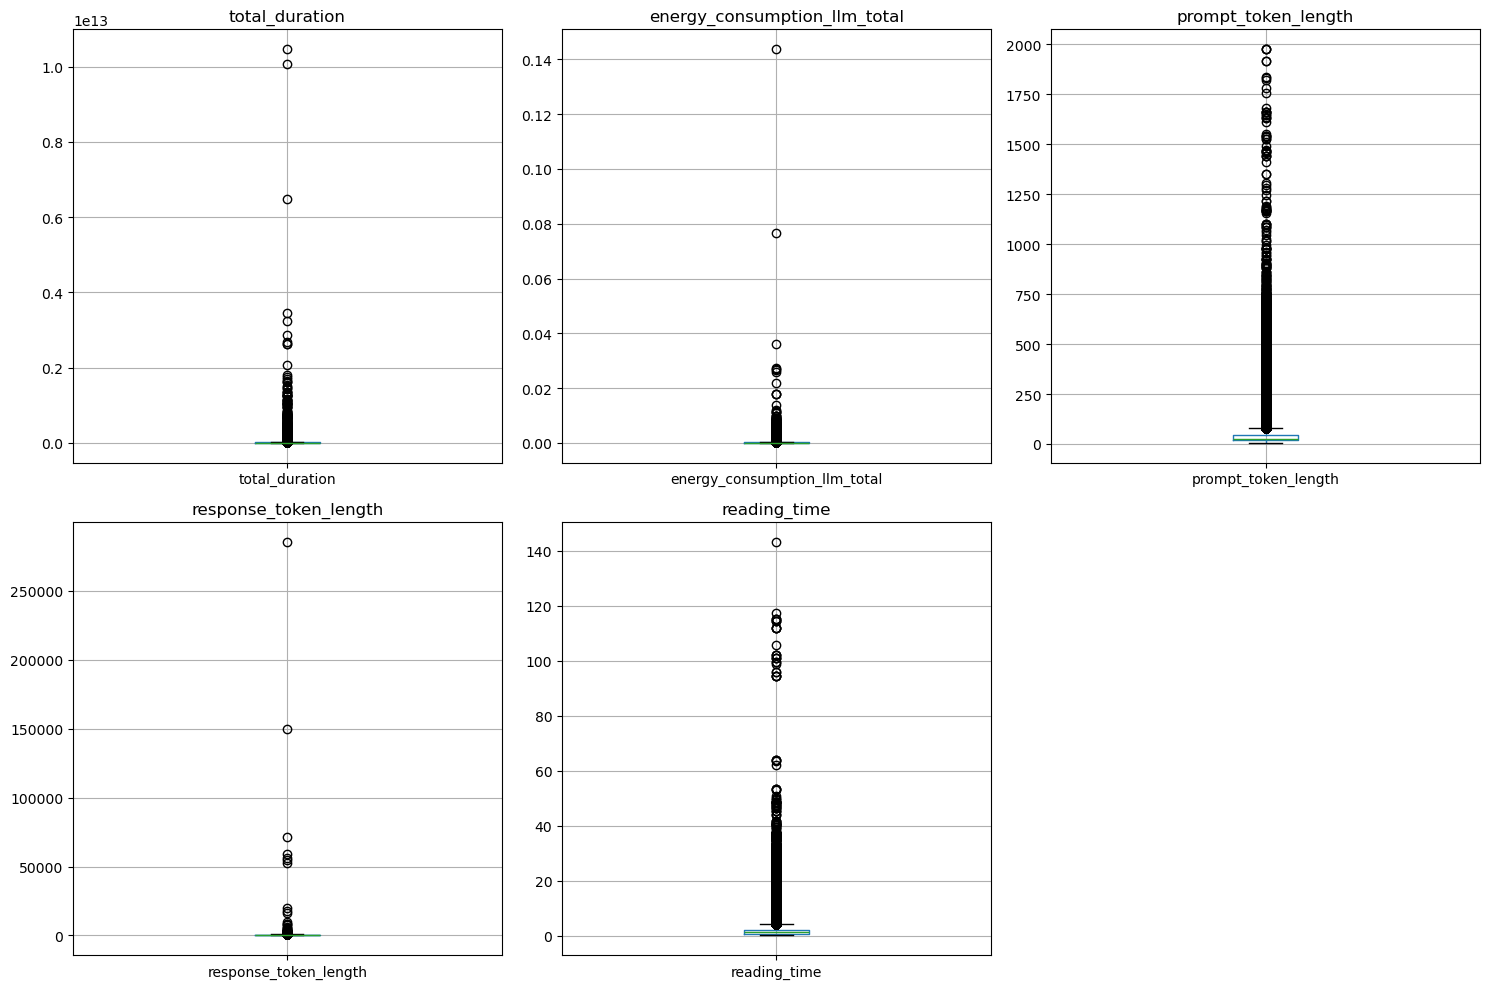

In [40]:
# Identify key numerical columns
numerical_cols = [
    'total_duration', 'load_duration', 'prompt_token_length',
    'prompt_duration', 'response_token_length', 'response_duration',
    'energy_consumption_llm_cpu', 'energy_consumption_llm_total',
    'energy_consumption_llm', 'energy_consumption_llm_gpu',
    'word_count', 'sentence_count', 'avg_word_length',
    'unique_word_count', 'avg_sentence_length', 'punctuation_count',
    'stop_word_count', 'long_word_count', 'named_entity_count', 'noun_count',
    'verb_count', 'adj_count', 'adverb_count', 'pronoun_count',
    'prop_adverbs', 'prop_pronouns', 'sentiment_polarity', 'sentiment_subjectivity',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
    'automated_readability_index', 'coleman_liau_index', 'linsear_write_formula',
    'dale_chall_readability_score', 'spache_readability', 'mcalpine_eflaw',
    'reading_time', 'fernandez_huerta', 'szigriszt_pazos', 'gutierrez_polini',
    'crawford', 'osman', 'gulpease_index', 'wiener_sachtextformel',
    'syllable_count', 'lexicon_count', 'char_count', 'letter_count',
    'polysyllabcount', 'monosyllabcount', 'question_marks', 'exclamation_marks',
    'sentence_embedding_variance', 'personal_pronouns', 'named_entities',
    'adjectives', 'adverbs', 'length_x_complexity', 'questions_about_entities',
    'desc_complexity_ratio', 'word_count_squared', 'avg_sentence_length_cubed',
    'lexical_diversity'
]
numerical_cols = [col for col in numerical_cols if col in df.columns]


# Examine descriptive statistics 
print("Descriptive statistics for selected numerical columns:")
display(df[numerical_cols].describe())

# Boxplot for outliers
import matplotlib.pyplot as plt

selected_cols_for_plotting = [
    'total_duration', 'energy_consumption_llm_total',
    'prompt_token_length', 'response_token_length', 'reading_time'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_cols_for_plotting):
    if col in df.columns:
        plt.subplot(2, 3, i + 1)
        df.boxplot(column=col)
        plt.title(col)

plt.tight_layout()
plt.show()

Descriptive statistics after capping outliers:


,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,energy_consumption_llm_cpu,energy_consumption_llm_total,energy_consumption_llm,energy_consumption_llm_gpu,...,personal_pronouns,named_entities,adjectives,adverbs,length_x_complexity,questions_about_entities,desc_complexity_ratio,word_count_squared,avg_sentence_length_cubed,lexical_diversity
count,7.337700e+04,7.337700e+04,73377.000000,7.337700e+04,73377.000000,7.337700e+04,7.337700e+04,73377.000000,73377.000000,73377.000000,...,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,7.337700e+04,73377.000000
mean,2.143854e+10,1.222071e+06,56.547692,1.688505e+09,260.317456,1.954122e+10,2.219021e-05,0.000120,0.000120,0.000091,...,0.274309,2.122981,2.386088,0.763959,1.904733,0.120433,0.116406,6575.840004,5.540300e+04,1.092105
std,3.716067e+10,6.312437e+05,84.315113,3.707078e+09,201.384183,3.484309e+10,9.834944e-05,0.000157,0.000157,0.000088,...,0.707036,4.094761,3.785247,1.409618,4.748429,0.710191,0.169132,21505.889846,2.658661e+05,0.903818
min,2.062720e+08,1.509040e+05,5.000000,1.222200e+07,2.000000,1.857900e+07,0.000000e+00,0.000003,0.000003,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.478813e+01,0.034483
25%,3.174785e+09,7.281410e+05,18.000000,1.546270e+08,61.000000,2.637012e+09,4.523581e-08,0.000029,0.000029,0.000020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.000000,7.290000e+02,0.818182
50%,6.743699e+09,1.295035e+06,26.000000,2.378590e+08,248.000000,5.806068e+09,1.039090e-07,0.000080,0.000080,0.000065,...,0.000000,1.000000,1.000000,0.000000,0.541090,0.000000,0.076923,400.000000,1.728000e+03,0.923077
75%,1.574297e+10,1.732869e+06,43.000000,1.410540e+09,412.000000,1.365249e+10,1.291692e-06,0.000165,0.000165,0.000132,...,0.000000,2.000000,3.000000,1.000000,1.249826,0.000000,0.142857,1089.000000,6.331625e+03,1.000000
max,1.813835e+11,2.870549e+06,479.000000,2.667776e+10,896.000000,1.724113e+11,7.775655e-04,0.001271,0.001271,0.000373,...,4.000000,24.000000,22.000000,8.000000,31.172798,6.000000,1.100000,142884.000000,1.964867e+06,6.058824


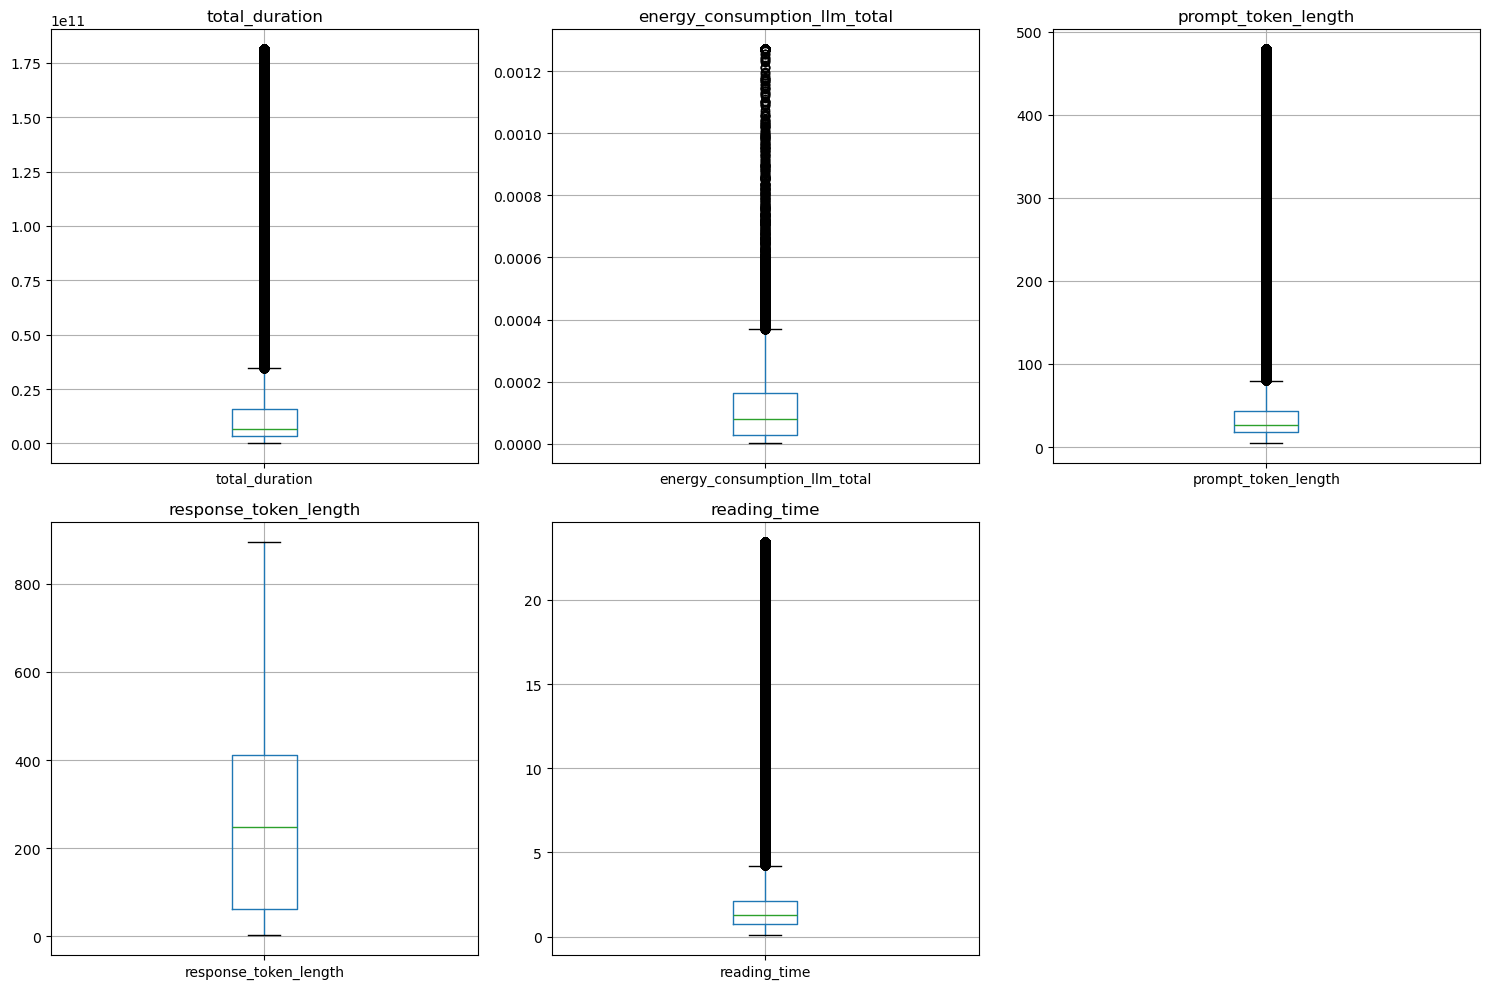

In [41]:
import numpy as np

# Identify columns for outlier handling
outlier_cols = [
    'total_duration', 'load_duration', 'prompt_token_length',
    'prompt_duration', 'response_token_length', 'response_duration',
    'energy_consumption_llm_cpu', 'energy_consumption_llm_total',
    'energy_consumption_llm', 'energy_consumption_llm_gpu',
    'word_count', 'sentence_count', 'avg_word_length',
    'unique_word_count', 'avg_sentence_length', 'punctuation_count',
    'stop_word_count', 'long_word_count', 'named_entity_count', 'noun_count',
    'verb_count', 'adj_count', 'adverb_count', 'pronoun_count',
    'prop_adverbs', 'prop_pronouns', 'sentiment_polarity', 'sentiment_subjectivity',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
    'automated_readability_index', 'coleman_liau_index', 'linsear_write_formula',
    'dale_chall_readability_score', 'spache_readability', 'mcalpine_eflaw',
    'reading_time', 'fernandez_huerta', 'szigriszt_pazos', 'gutierrez_polini',
    'crawford', 'osman', 'gulpease_index', 'wiener_sachtextformel',
    'syllable_count', 'lexicon_count', 'char_count', 'letter_count',
    'polysyllabcount', 'monosyllabcount', 'question_marks', 'exclamation_marks',
    'sentence_embedding_variance', 'personal_pronouns', 'named_entities',
    'adjectives', 'adverbs', 'length_x_complexity', 'questions_about_entities',
    'desc_complexity_ratio', 'word_count_squared', 'avg_sentence_length_cubed',
    'lexical_diversity'
]
outlier_cols = [col for col in outlier_cols if col in df.columns]

# Cap outliers at the 99th percentile for the selected columns
for col in outlier_cols:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# Re-examine descriptive statistics for the modified columns
print("Descriptive statistics after capping outliers:")
display(df[outlier_cols].describe())

# Re-visualize with box plots for the subset of columns
import matplotlib.pyplot as plt

selected_cols_for_plotting = [
    'total_duration', 'energy_consumption_llm_total',
    'prompt_token_length', 'response_token_length', 'reading_time'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_cols_for_plotting):
    if col in df.columns:
        plt.subplot(2, 3, i + 1)
        df.boxplot(column=col)
        plt.title(col)

plt.tight_layout()
plt.show()

## Features Engineering

In [42]:
# Extract date components from 'created_at'
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce') # Ensure datetime type
    df['hour'] = df['created_at'].dt.hour
    df['day_of_week'] = df['created_at'].dt.dayofweek
    df['month'] = df['created_at'].dt.month

# Calculate inference speed (tokens per second)
if 'prompt_token_length' in df.columns and 'prompt_duration' in df.columns:
    df['prompt_speed_tps'] = df.apply(
        lambda row: row['prompt_token_length'] / (row['prompt_duration'] / 1e9)
        if row['prompt_duration'] > 0 else 0, axis=1
    )

if 'response_token_length' in df.columns and 'response_duration' in df.columns:
    df['response_speed_tps'] = df.apply(
        lambda row: row['response_token_length'] / (row['response_duration'] / 1e9)
        if row['response_duration'] > 0 else 0, axis=1
    )

# Calculate total token length and total duration
if 'prompt_token_length' in df.columns and 'response_token_length' in df.columns:
    df['total_token_length'] = df['prompt_token_length'] + df['response_token_length']

if 'load_duration' in df.columns and 'prompt_duration' in df.columns and 'response_duration' in df.columns:
    df['total_inference_duration'] = df['load_duration'] + df['prompt_duration'] + df['response_duration']
elif 'total_duration' in df.columns:
     df['total_inference_duration'] = df['total_duration'] 

# Display the new columns and a few relevant original columns to verify
display(df[['created_at', 'hour', 'day_of_week', 'month',
            'prompt_token_length', 'prompt_duration', 'prompt_speed_tps',
            'response_token_length', 'response_duration', 'response_speed_tps',
            'total_token_length', 'total_duration', 'total_inference_duration']].head())

,created_at,hour,day_of_week,month,prompt_token_length,prompt_duration,prompt_speed_tps,response_token_length,response_duration,response_speed_tps,total_token_length,total_duration,total_inference_duration
0,2024-05-20 01:29:27.691485835+00:00,1,0,5,27.0,6.298400e+08,42.868030,481.0,1.724113e+11,2.789840,508.0,1.813835e+11,1.730415e+11
1,2024-05-20 01:30:34.454555386+00:00,1,0,5,39.0,1.437697e+10,2.712672,119.0,4.833704e+10,2.461880,158.0,6.272181e+10,6.271444e+10
2,2024-05-20 01:34:30.874894395+00:00,1,0,5,35.0,1.301101e+10,2.690029,519.0,1.724113e+11,3.010243,554.0,1.813835e+11,1.854227e+11
3,2024-05-20 01:36:11.699366237+00:00,1,0,5,83.0,2.667776e+10,3.111206,162.0,6.776408e+10,2.390647,245.0,9.673783e+10,9.444220e+10
4,2024-05-20 01:38:59.260219141+00:00,1,0,5,34.0,1.197915e+10,2.838265,361.0,1.521154e+11,2.373198,395.0,1.640967e+11,1.640949e+11


## Scaling :

In [43]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns to scale
numerical_cols_to_scale = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude datetime-related numerical features and 'Unnamed' columns
cols_to_exclude = ['hour', 'day_of_week', 'month', 'index', 'Unnamed: 0',
                   'Unnamed: 0.1', 'Unnamed: 0.2']

numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col not in cols_to_exclude and col in df.columns]

print("Numerical columns selected for scaling:")
print(numerical_cols_to_scale)

Numerical columns selected for scaling:
['total_duration', 'load_duration', 'prompt_token_length', 'prompt_duration', 'response_token_length', 'response_duration', 'energy_consumption_monitoring', 'energy_consumption_llm_cpu', 'energy_consumption_llm_total', 'energy_consumption_llm', 'word_count', 'sentence_count', 'avg_word_length', 'word_diversity', 'unique_word_count', 'avg_sentence_length', 'punctuation_count', 'stop_word_count', 'long_word_count', 'named_entity_count', 'noun_count', 'verb_count', 'adj_count', 'adverb_count', 'pronoun_count', 'prop_adverbs', 'prop_pronouns', 'sentiment_polarity', 'sentiment_subjectivity', 'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index', 'automated_readability_index', 'coleman_liau_index', 'linsear_write_formula', 'dale_chall_readability_score', 'spache_readability', 'mcalpine_eflaw', 'reading_time', 'fernandez_huerta', 'szigriszt_pazos', 'gutierrez_polini', 'crawford', 'osman', 'gulpease_index', 'wiener_sachtextformel', '

In [44]:
# Instantiate the MinMaxScaler
scaler = MinMaxScaler()

# Apply the scaler 
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

# Display descriptive statistics 
print("\nDescriptive statistics of scaled numerical columns:")
display(df[numerical_cols_to_scale].describe())


Descriptive statistics of scaled numerical columns:


,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,energy_consumption_monitoring,energy_consumption_llm_cpu,energy_consumption_llm_total,energy_consumption_llm,...,questions_about_entities,desc_complexity_ratio,word_count_squared,avg_sentence_length_cubed,lexical_diversity,energy_consumption_llm_gpu,prompt_speed_tps,response_speed_tps,total_token_length,total_inference_duration
count,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,...,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000
mean,0.117191,0.393863,0.108750,0.062863,0.288946,0.113245,0.002572,0.028538,0.092402,0.092402,...,0.020072,0.105824,0.045962,0.028190,0.175558,0.243420,0.102087,0.392693,0.223672,0.105837
std,0.205107,0.232105,0.177880,0.139021,0.225262,0.202115,0.009351,0.126484,0.124215,0.124215,...,0.118365,0.153756,0.150522,0.135311,0.150028,0.235176,0.147894,0.324080,0.177221,0.185057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.016385,0.212247,0.027426,0.005340,0.065996,0.015189,0.000084,0.000058,0.020801,0.020801,...,0.000000,0.000000,0.000784,0.000363,0.130089,0.053485,0.007478,0.072997,0.057227,0.014701
50%,0.036083,0.420691,0.044304,0.008462,0.275168,0.033572,0.000536,0.000134,0.060715,0.060715,...,0.000000,0.069930,0.002737,0.000872,0.147501,0.174085,0.049816,0.361945,0.211299,0.032575
75%,0.085754,0.581681,0.080169,0.052439,0.458613,0.079086,0.001564,0.001661,0.127726,0.127726,...,0.000000,0.129870,0.007559,0.003215,0.160269,0.355090,0.132453,0.786686,0.332355,0.077712
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
print("First 5 rows of the DataFrame after cleaning and preprocessing:")
display(df.head())

print("\nData types of all columns:")
print(df.dtypes)

print("\nShape of the DataFrame (rows, columns):")
print(df.shape)

# Check for any remaining missing values
missing_values_after_cleaning = df.isnull().sum()
print("\nRemaining missing values per column:")
print(missing_values_after_cleaning[missing_values_after_cleaning > 0])

# Display descriptive statistics for the numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())

# Display value counts for categorical columns ('model_name')
print("\nValue counts for 'model_name':")
print(df['model_name'].value_counts())

First 5 rows of the DataFrame after cleaning and preprocessing:


,Unnamed: 0,index,model_name,created_at,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,...,avg_sentence_length_cubed,lexical_diversity,energy_consumption_llm_gpu,hour,day_of_week,month,prompt_speed_tps,response_speed_tps,total_token_length,total_inference_duration
0,0,0,codellama:7b,2024-05-20 01:29:27.691485835+00:00,1.000000,0.059445,0.046414,0.023162,0.535794,1.000000,...,0.005412,0.130089,0.0,1,0,5,0.019089,0.020029,0.363903,0.869037
1,1,0,codellama:7b,2024-05-20 01:30:34.454555386+00:00,0.345052,0.103857,0.071730,0.538701,0.130872,0.280281,...,0.019996,0.130976,0.0,1,0,5,0.000906,0.017125,0.107117,0.314388
2,2,0,codellama:7b,2024-05-20 01:34:30.874894395+00:00,1.000000,0.098706,0.063291,0.487475,0.578300,1.000000,...,0.001111,0.128348,0.0,1,0,5,0.000896,0.021981,0.397652,0.931281
3,3,0,codellama:7b,2024-05-20 01:36:11.699366237+00:00,0.532802,0.078762,0.164557,1.000000,0.178971,0.392972,...,0.018282,0.107453,0.0,1,0,5,0.001086,0.016495,0.170946,0.473893
4,4,0,codellama:7b,2024-05-20 01:38:59.260219141+00:00,0.904586,0.059525,0.061181,0.448779,0.401566,0.882270,...,0.001245,0.147974,0.0,1,0,5,0.000963,0.016340,0.280998,0.824060



Data types of all columns:
Unnamed: 0                                int64
index                                     int64
model_name                               object
created_at                  datetime64[ns, UTC]
total_duration                          float64
                                   ...         
month                                     int32
prompt_speed_tps                        float64
response_speed_tps                      float64
total_token_length                      float64
total_inference_duration                float64
Length: 85, dtype: object

Shape of the DataFrame (rows, columns):
(73377, 85)

Remaining missing values per column:
Series([], dtype: int64)

Descriptive statistics for numerical columns:


,Unnamed: 0,index,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,energy_consumption_monitoring,energy_consumption_llm_cpu,...,avg_sentence_length_cubed,lexical_diversity,energy_consumption_llm_gpu,hour,day_of_week,month,prompt_speed_tps,response_speed_tps,total_token_length,total_inference_duration
count,73377.000000,73377.0,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,...,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000,73377.000000
mean,3524.809995,0.0,0.117191,0.393863,0.108750,0.062863,0.288946,0.113245,0.002572,0.028538,...,0.028190,0.175558,0.243420,12.959388,2.914646,5.285430,0.102087,0.392693,0.223672,0.105837
std,2674.677314,0.0,0.205107,0.232105,0.177880,0.139021,0.225262,0.202115,0.009351,0.126484,...,0.135311,0.150028,0.235176,6.799646,2.102530,0.451622,0.147894,0.324080,0.177221,0.185057
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,1429.000000,0.0,0.016385,0.212247,0.027426,0.005340,0.065996,0.015189,0.000084,0.000058,...,0.000363,0.130089,0.053485,8.000000,1.000000,5.000000,0.007478,0.072997,0.057227,0.014701
50%,2958.000000,0.0,0.036083,0.420691,0.044304,0.008462,0.275168,0.033572,0.000536,0.000134,...,0.000872,0.147501,0.174085,14.000000,3.000000,5.000000,0.049816,0.361945,0.211299,0.032575
75%,4862.000000,0.0,0.085754,0.581681,0.080169,0.052439,0.458613,0.079086,0.001564,0.001661,...,0.003215,0.160269,0.355090,19.000000,5.000000,6.000000,0.132453,0.786686,0.332355,0.077712
max,11827.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,23.000000,6.000000,6.000000,1.000000,1.000000,1.000000,1.000000



Value counts for 'model_name':
model_name
gemma:2b         31898
gemma:7b         23163
codellama:7b      8456
llama3            5101
codellama         3572
llama3:70b        1026
codellama:70b      161
Name: count, dtype: int64


## Features Selection

In [46]:
# Select columns relevant for building a predictive model
selected_cols = [
    'model_name',             # Categorical feature: The model used
    'total_duration',         # Numerical feature: Total time for the request
    'load_duration',          # Numerical feature: Time to load the model
    'prompt_token_length',    # Numerical feature: Number of tokens in the prompt
    'prompt_duration',        # Numerical feature: Time to process the prompt
    'response_token_length',  # Numerical feature: Number of tokens in the response
    'response_duration',      # Numerical feature: Time to generate the response
    'prompt_speed_tps',       # Engineered feature: Prompt tokens per second
    'response_speed_tps',     # Engineered feature: Response tokens per second
    'total_token_length',     # Engineered feature: Total tokens
    'total_inference_duration', # Engineered feature: Total inference duration
    # Target variables related to energy consumption
    'energy_consumption_llm_cpu',
    'energy_consumption_llm_gpu',
    'energy_consumption_llm_total',
    'energy_consumption_llm',
    'energy_consumption_monitoring' 
]

# Create a new DataFrame with the selected columns
df_model = df[selected_cols].copy()

print("DataFrame for modeling created with selected columns.")
display(df_model.head())
print("\nSelected columns for modeling:")
print(df_model.columns)

DataFrame for modeling created with selected columns.


,model_name,total_duration,load_duration,prompt_token_length,prompt_duration,response_token_length,response_duration,prompt_speed_tps,response_speed_tps,total_token_length,total_inference_duration,energy_consumption_llm_cpu,energy_consumption_llm_gpu,energy_consumption_llm_total,energy_consumption_llm,energy_consumption_monitoring
0,codellama:7b,1.000000,0.059445,0.046414,0.023162,0.535794,1.000000,0.019089,0.020029,0.363903,0.869037,0.670476,0.0,0.408759,0.408759,0.027149
1,codellama:7b,0.345052,0.103857,0.071730,0.538701,0.130872,0.280281,0.000906,0.017125,0.107117,0.314388,0.190391,0.0,0.114336,0.114336,0.007555
2,codellama:7b,1.000000,0.098706,0.063291,0.487475,0.578300,1.000000,0.000896,0.021981,0.397652,0.931281,0.701361,0.0,0.427700,0.427700,0.028103
3,codellama:7b,0.532802,0.078762,0.164557,1.000000,0.178971,0.392972,0.001086,0.016495,0.170946,0.473893,0.285231,0.0,0.172499,0.172499,0.011298
4,codellama:7b,0.904586,0.059525,0.061181,0.448779,0.401566,0.882270,0.000963,0.016340,0.280998,0.824060,0.485902,0.0,0.295565,0.295565,0.019307



Selected columns for modeling:
Index(['model_name', 'total_duration', 'load_duration', 'prompt_token_length',
       'prompt_duration', 'response_token_length', 'response_duration',
       'prompt_speed_tps', 'response_speed_tps', 'total_token_length',
       'total_inference_duration', 'energy_consumption_llm_cpu',
       'energy_consumption_llm_gpu', 'energy_consumption_llm_total',
       'energy_consumption_llm', 'energy_consumption_monitoring'],
      dtype='object')


### Analysis of potential target variables :

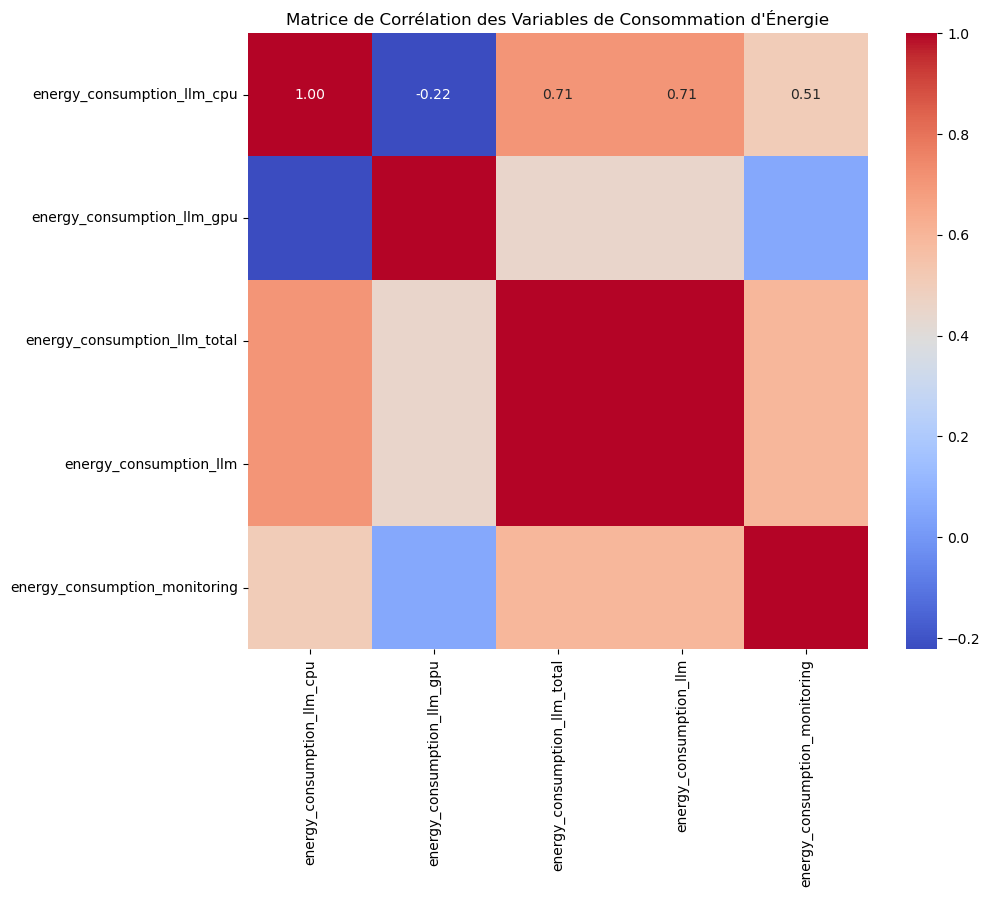

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the energy consumption columns
energy_cols = ['energy_consumption_llm_cpu',
               'energy_consumption_llm_gpu',
               'energy_consumption_llm_total',
               'energy_consumption_llm',
               'energy_consumption_monitoring']

# Ensure the selected columns exist in the DataFrame
energy_cols = [col for col in energy_cols if col in df_model.columns]

# Calculate the correlation matrix
correlation_matrix = df_model[energy_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables de Consommation d\'Énergie')
plt.show()

Training the Random Forest model...
Training complete.

Top 20 Feature Importances:
cat__model_name_llama3:70b       0.402433
num__response_token_length       0.260234
cat__model_name_gemma:2b         0.105822
num__total_inference_duration    0.073146
num__total_duration              0.053170
cat__model_name_codellama:70b    0.041505
num__response_duration           0.037531
num__response_speed_tps          0.004811
num__total_token_length          0.004434
num__prompt_speed_tps            0.004263
cat__model_name_gemma:7b         0.003296
num__prompt_duration             0.003157
num__load_duration               0.002692
cat__model_name_codellama:7b     0.001726
num__prompt_token_length         0.001089
cat__model_name_llama3           0.000578
cat__model_name_codellama        0.000113
dtype: float64


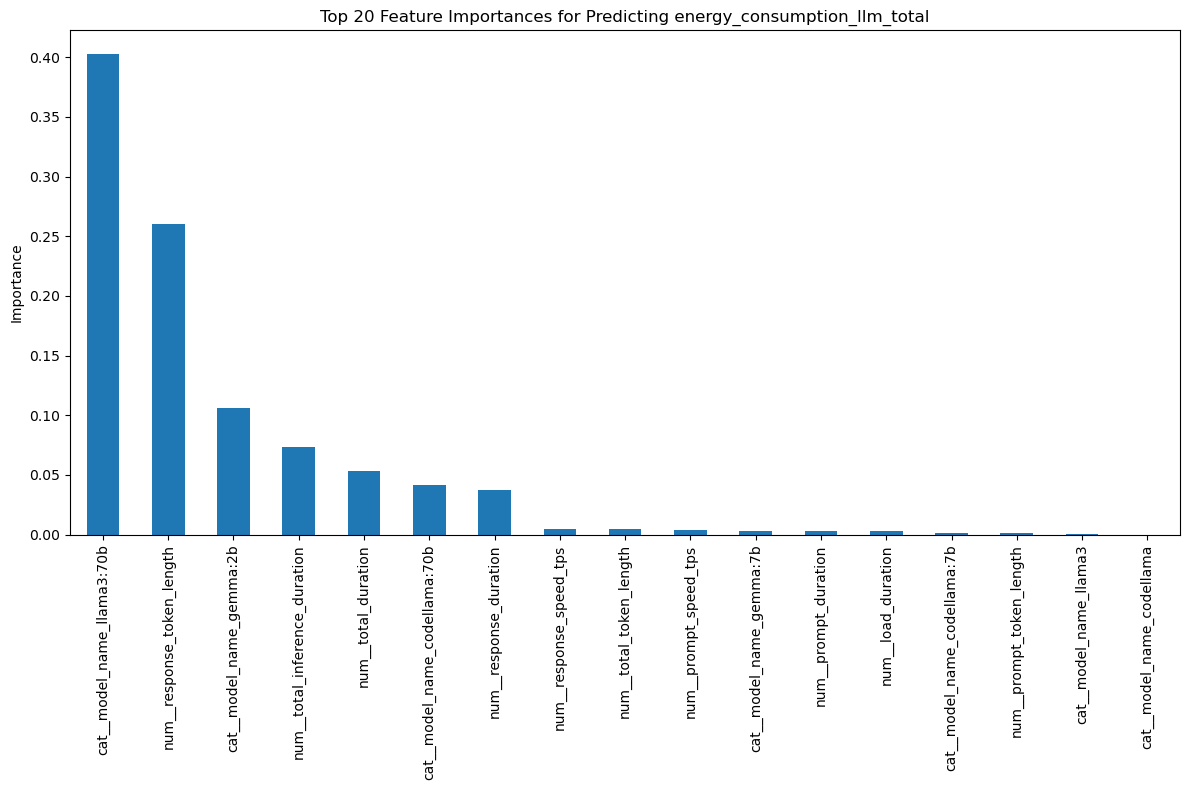

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

# Define features (X) and target variable (y)
features = [col for col in df_model.columns if col not in ['energy_consumption_llm_cpu',
                                                           'energy_consumption_llm_gpu',
                                                           'energy_consumption_llm_total',
                                                           'energy_consumption_llm',
                                                           'energy_consumption_monitoring']]
X = df_model[features]
y = df_model['energy_consumption_llm_total']

# Identify categorical and numerical features
categorical_features = ['model_name']
numerical_features = [col for col in features if col not in categorical_features]

# Create a preprocessor to handle categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a Random Forest Regressor model pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Training complete.")

# Get feature importances
feature_importances = model.named_steps['regressor'].feature_importances_

# Get feature names after one-hot encoding 
transformed_features = preprocessor.get_feature_names_out(features)

# Create a pandas Series for better visualization
feature_importances_series = pd.Series(feature_importances, index=transformed_features)

# Display the top N
top_n = 20
print(f"\nTop {top_n} Feature Importances:")
print(feature_importances_series.sort_values(ascending=False).head(top_n))

# Visualize feature importances
plt.figure(figsize=(12, 8))
feature_importances_series.sort_values(ascending=False).head(top_n).plot(kind='bar')
plt.title(f'Top {top_n} Feature Importances for Predicting energy_consumption_llm_total')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Selection of important features :

In [49]:
# Define the importance threshold
importance_threshold = 0.003

# Get transformed features above threshold
important_transformed_features = feature_importances_series[feature_importances_series > importance_threshold].index.tolist()

# Map transformed features back to original column names
original_important_features = set() 
for transformed_feature in important_transformed_features:
    if transformed_feature.startswith('num__'):
        original_important_features.add(transformed_feature.replace('num__', ''))
    elif transformed_feature.startswith('cat__'):
        original_cat_cols = [col for name, transformer, col in preprocessor.transformers_ if name == 'cat'][0]
        for original_cat_col in original_cat_cols:
             if original_cat_col in transformed_feature:
                 original_important_features.add(original_cat_col)
                 break 
    else:
        original_important_features.add(transformed_feature)

original_important_features = list(original_important_features)

# Add target column
target_column = 'energy_consumption_llm_total'
if target_column not in original_important_features:
    original_important_features.append(target_column)

# Create DataFrame with selected features
final_selected_cols = [col for col in original_important_features if col in df_model.columns]
df_important = df_model[final_selected_cols].copy()

print(f"Created a new DataFrame 'df_important' with features having importance > {importance_threshold} and the target column.")
print("\nColumns in the new DataFrame:")
print(df_important.columns)
display(df_important.head())

Created a new DataFrame 'df_important' with features having importance > 0.003 and the target column.

Columns in the new DataFrame:
Index(['total_token_length', 'response_token_length',
       'total_inference_duration', 'response_speed_tps', 'prompt_duration',
       'model_name', 'prompt_speed_tps', 'response_duration', 'total_duration',
       'energy_consumption_llm_total'],
      dtype='object')


,total_token_length,response_token_length,total_inference_duration,response_speed_tps,prompt_duration,model_name,prompt_speed_tps,response_duration,total_duration,energy_consumption_llm_total
0,0.363903,0.535794,0.869037,0.020029,0.023162,codellama:7b,0.019089,1.000000,1.000000,0.408759
1,0.107117,0.130872,0.314388,0.017125,0.538701,codellama:7b,0.000906,0.280281,0.345052,0.114336
2,0.397652,0.578300,0.931281,0.021981,0.487475,codellama:7b,0.000896,1.000000,1.000000,0.427700
3,0.170946,0.178971,0.473893,0.016495,1.000000,codellama:7b,0.001086,0.392972,0.532802,0.172499
4,0.280998,0.401566,0.824060,0.016340,0.448779,codellama:7b,0.000963,0.882270,0.904586,0.295565


In [50]:
df_important.head()

,total_token_length,response_token_length,total_inference_duration,response_speed_tps,prompt_duration,model_name,prompt_speed_tps,response_duration,total_duration,energy_consumption_llm_total
0,0.363903,0.535794,0.869037,0.020029,0.023162,codellama:7b,0.019089,1.000000,1.000000,0.408759
1,0.107117,0.130872,0.314388,0.017125,0.538701,codellama:7b,0.000906,0.280281,0.345052,0.114336
2,0.397652,0.578300,0.931281,0.021981,0.487475,codellama:7b,0.000896,1.000000,1.000000,0.427700
3,0.170946,0.178971,0.473893,0.016495,1.000000,codellama:7b,0.001086,0.392972,0.532802,0.172499
4,0.280998,0.401566,0.824060,0.016340,0.448779,codellama:7b,0.000963,0.882270,0.904586,0.295565


In [51]:
df_important.shape

(73377, 10)

### Encoder Categorical Feature :

In [52]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Apply Label Encoding to the 'model_name' column
df_important['model_name_encoded'] = label_encoder.fit_transform(df_important['model_name'])


print("DataFrame after Label Encoding 'model_name':")
display(df_important[['model_name', 'model_name_encoded']].head())

print("\nUnique values in original 'model_name' and their encoded values:")

# Create a mapping of original labels to encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

# Drop the original 'model_name' column
if 'model_name' in df_important.columns:
    df_important = df_important.drop(columns=['model_name'])
    print("Original 'model_name' column dropped.")
else:
    print("'model_name' column not found in the DataFrame.")

# Display the columns of the updated DataFrame
print("\nColumns after dropping 'model_name':")
print(df_important.columns)

display(df_important.head())

DataFrame after Label Encoding 'model_name':


,model_name,model_name_encoded
0,codellama:7b,2
1,codellama:7b,2
2,codellama:7b,2
3,codellama:7b,2
4,codellama:7b,2



Unique values in original 'model_name' and their encoded values:
{'codellama': 0, 'codellama:70b': 1, 'codellama:7b': 2, 'gemma:2b': 3, 'gemma:7b': 4, 'llama3': 5, 'llama3:70b': 6}
Original 'model_name' column dropped.

Columns after dropping 'model_name':
Index(['total_token_length', 'response_token_length',
       'total_inference_duration', 'response_speed_tps', 'prompt_duration',
       'prompt_speed_tps', 'response_duration', 'total_duration',
       'energy_consumption_llm_total', 'model_name_encoded'],
      dtype='object')


,total_token_length,response_token_length,total_inference_duration,response_speed_tps,prompt_duration,prompt_speed_tps,response_duration,total_duration,energy_consumption_llm_total,model_name_encoded
0,0.363903,0.535794,0.869037,0.020029,0.023162,0.019089,1.000000,1.000000,0.408759,2
1,0.107117,0.130872,0.314388,0.017125,0.538701,0.000906,0.280281,0.345052,0.114336,2
2,0.397652,0.578300,0.931281,0.021981,0.487475,0.000896,1.000000,1.000000,0.427700,2
3,0.170946,0.178971,0.473893,0.016495,1.000000,0.001086,0.392972,0.532802,0.172499,2
4,0.280998,0.401566,0.824060,0.016340,0.448779,0.000963,0.882270,0.904586,0.295565,2


## Save the model 

In [53]:
df_important.to_csv('df_preprocess.csv', index=False)

print("Le DataFrame 'df_preprocess' a été sauvegardé en tant que 'df_preprocess.csv'.")

Le DataFrame 'df_preprocess' a été sauvegardé en tant que 'df_preprocess.csv'.


## Visualization : 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

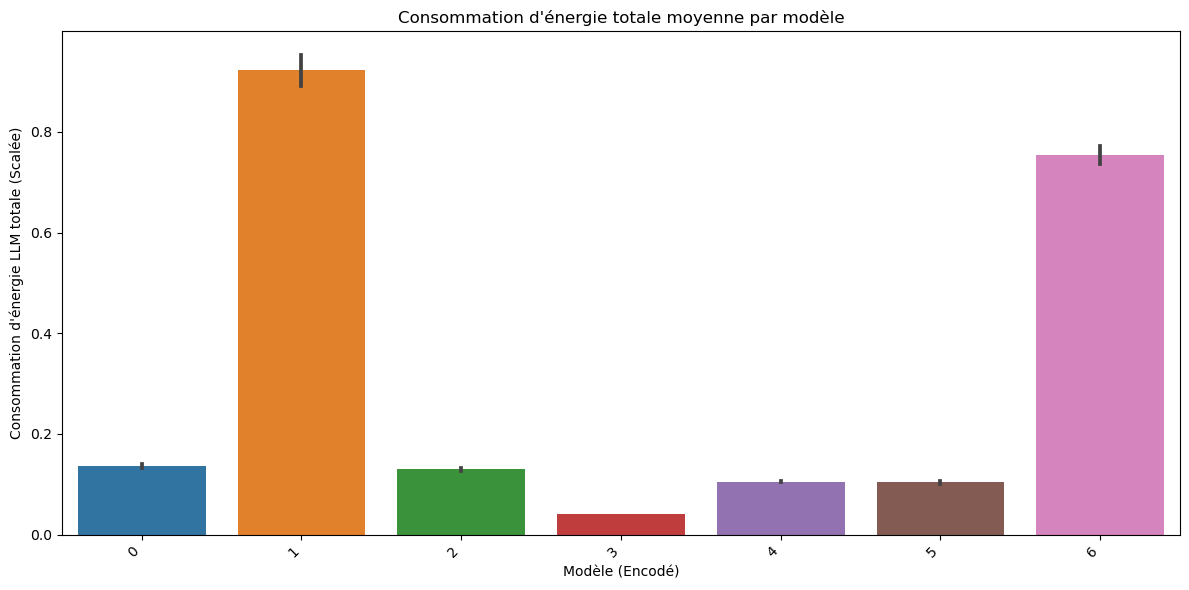

{'codellama': 0, 'codellama:70b': 1, 'codellama:7b': 2, 'gemma:2b': 3, 'gemma:7b': 4, 'llama3': 5, 'llama3:70b': 6}


In [54]:
# Consommation d'énergie totale moyenne par modèle
plt.figure(figsize=(12, 6))
sns.barplot(x='model_name_encoded', y='energy_consumption_llm_total', data=df_important)
plt.title('Consommation d\'énergie totale moyenne par modèle')
plt.xlabel('Modèle (Encodé)')
plt.ylabel('Consommation d\'énergie LLM totale (Scalée)')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

print(label_mapping)

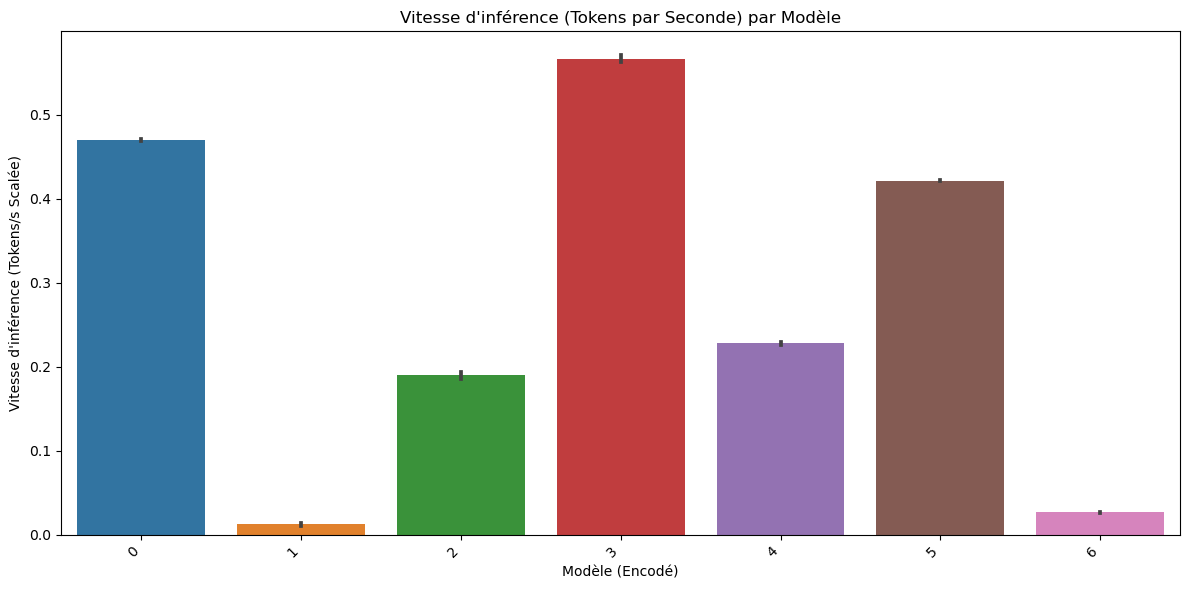

{'codellama': 0, 'codellama:70b': 1, 'codellama:7b': 2, 'gemma:2b': 3, 'gemma:7b': 4, 'llama3': 5, 'llama3:70b': 6}


In [55]:
# Inference Speed by Model
plt.figure(figsize=(12, 6))
sns.barplot(x='model_name_encoded', y='response_speed_tps', data=df_important)
plt.title('Vitesse d\'inférence (Tokens par Seconde) par Modèle')
plt.xlabel('Modèle (Encodé)')
plt.ylabel('Vitesse d\'inférence (Tokens/s Scalée)')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

print(label_mapping)

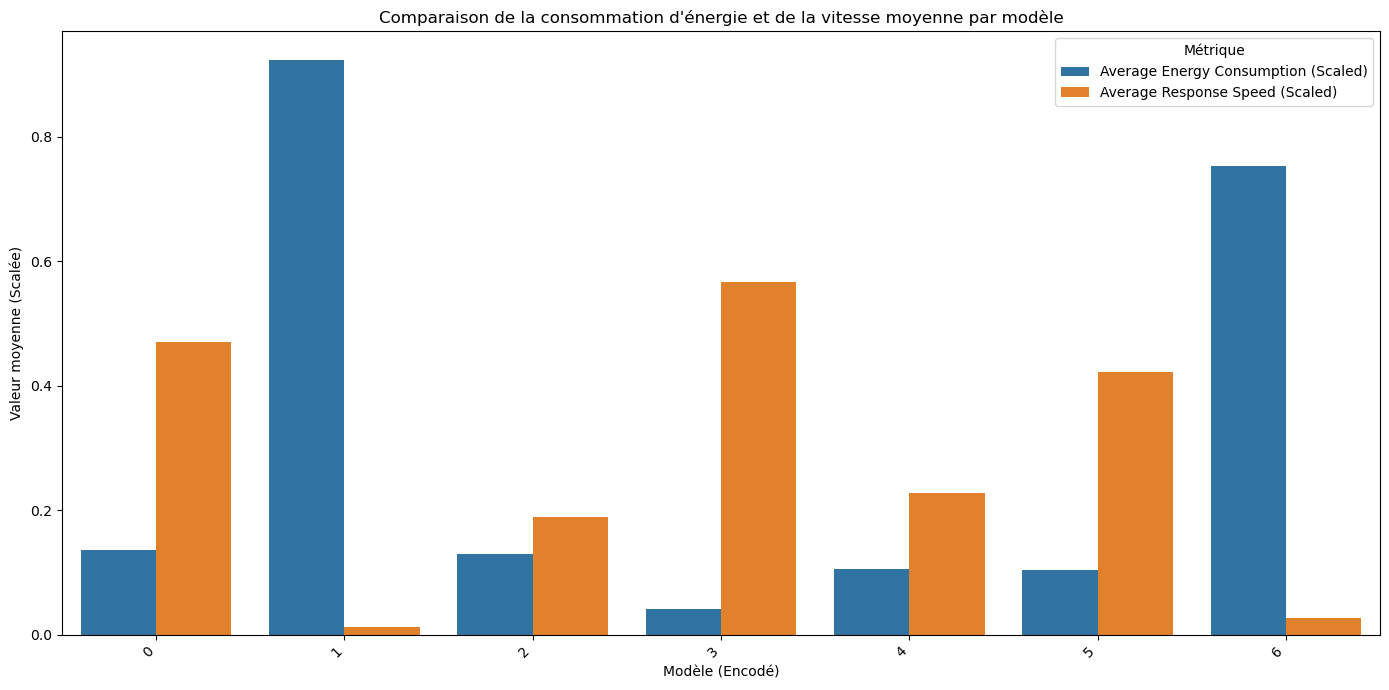

Note: The x-axis shows encoded model names. Refer to the label_mapping dictionary to understand the mapping.


In [56]:
# Define the columns for the grouped bar plot
energy_col = 'energy_consumption_llm_total'
speed_col = 'response_speed_tps'
model_col = 'model_name_encoded' 

if energy_col in df_important.columns and speed_col in df_important.columns and model_col in df_important.columns:

    # Calculate the mean energy consumption and speed for each model
    mean_metrics_by_model = df_important.groupby(model_col)[[energy_col, speed_col]].mean().reset_index()

    # Rename columns for clarity in the plot
    mean_metrics_by_model = mean_metrics_by_model.rename(columns={
        energy_col: 'Average Energy Consumption (Scaled)',
        speed_col: 'Average Response Speed (Scaled)'
    })

    mean_metrics_melted = mean_metrics_by_model.melt(
        id_vars=model_col,
        var_name='Metric',
        value_name='Average Value'
    )

    # Create the grouped bar plot
    plt.figure(figsize=(14, 7))
    sns.barplot(x=model_col, y='Average Value', hue='Metric', data=mean_metrics_melted)
    plt.title('Comparaison de la consommation d\'énergie et de la vitesse moyenne par modèle')
    plt.xlabel('Modèle (Encodé)')
    plt.ylabel('Valeur moyenne (Scalée)')
    plt.xticks(rotation=45, ha='right') 
    plt.legend(title='Métrique')
    plt.tight_layout()
    plt.show()

    print("Note: The x-axis shows encoded model names. Refer to the label_mapping dictionary to understand the mapping.")
    print(label_mapping) 

else:
    print("Required columns for grouped bar plot are not found in the DataFrame.")

/opt/conda/envs/Python-RT24.1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


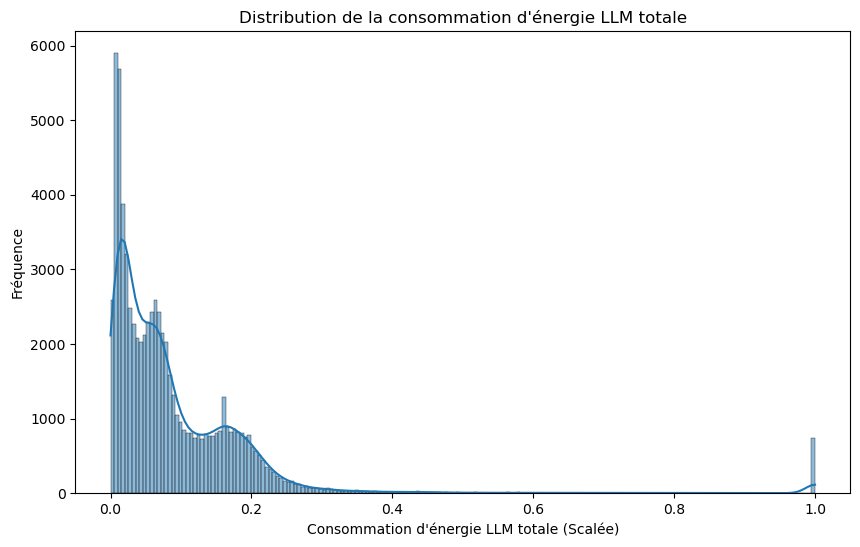

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(df_important['energy_consumption_llm_total'], kde=True)
plt.title('Distribution de la consommation d\'énergie LLM totale')
plt.xlabel('Consommation d\'énergie LLM totale (Scalée)')
plt.ylabel('Fréquence')
plt.show()

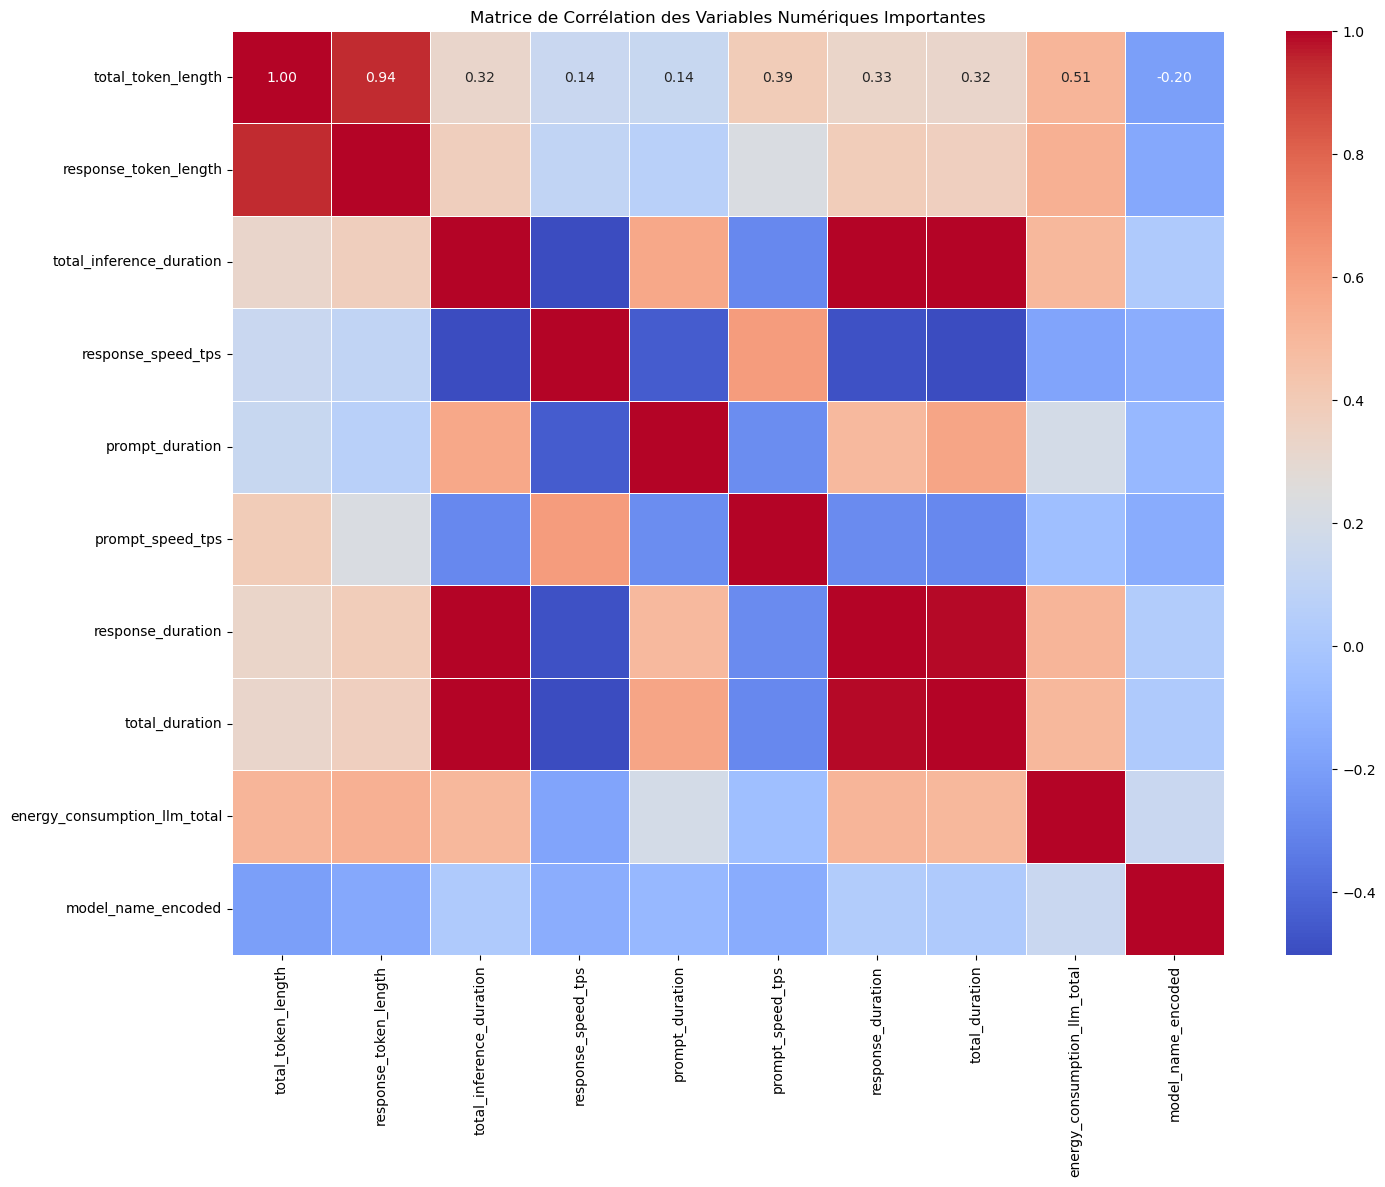

In [58]:
# Select only numerical columns
numerical_cols_important = df_important.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix_important = df_important[numerical_cols_important].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_important, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Variables Numériques Importantes')
plt.show()

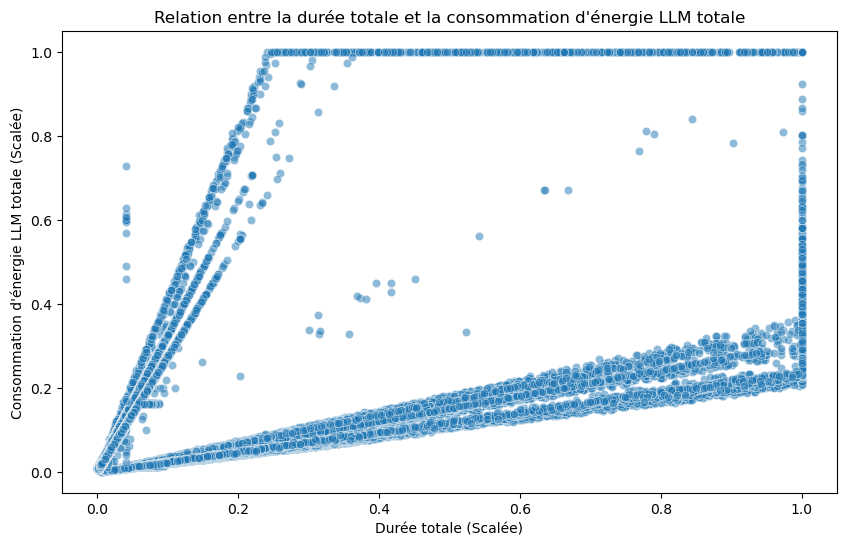

In [59]:
# Scatter plot for total_duration vs energy_consumption_llm_total

if 'total_duration' in df_important.columns and 'energy_consumption_llm_total' in df_important.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='total_duration', y='energy_consumption_llm_total', data=df_important, alpha=0.5)
    plt.title('Relation entre la durée totale et la consommation d\'énergie LLM totale')
    plt.xlabel('Durée totale (Scalée)')
    plt.ylabel('Consommation d\'énergie LLM totale (Scalée)')
    plt.show()
else:
    print("One or both columns ('total_duration', 'energy_consumption_llm_total') not found in the DataFrame.")

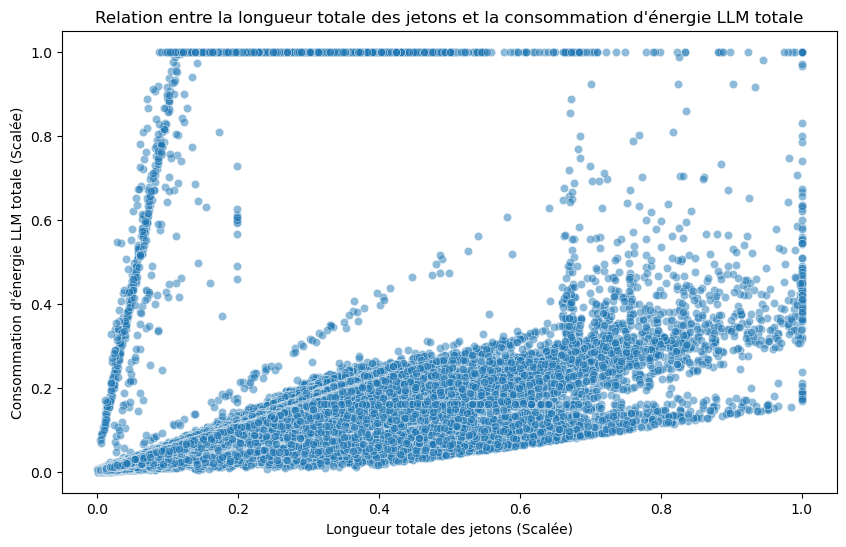

In [60]:
# Scatter plot for total_token_length vs energy_consumption_llm_total
if 'total_token_length' in df_important.columns and 'energy_consumption_llm_total' in df_important.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='total_token_length', y='energy_consumption_llm_total', data=df_important, alpha=0.5)
    plt.title('Relation entre la longueur totale des jetons et la consommation d\'énergie LLM totale')
    plt.xlabel('Longueur totale des jetons (Scalée)')
    plt.ylabel('Consommation d\'énergie LLM totale (Scalée)')
    plt.show()
else:
    print("One or both columns ('total_token_length', 'energy_consumption_llm_total') not found in the DataFrame.")